### # 🚗 Car Sales Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
 


In [2]:
df=pd.read_csv("car_sales_analysis_dataset.csv")


In [3]:
df.head()

,Sale_ID,Date,Brand,Model,Year,Price,Quantity,City,Salesperson,Payment_Method,Customer_Age,Revenue
0,1,2025-04-13,Honda,Civic,2022,27300.0,3,Irbid,Sara,Bank Transfer,31.0,81900.0
1,2,2025-05-30,Mercedes,C-Class,2023,47800.0,1,Salt,Omar,Installment,50.0,47800.0
2,3,2025-11-10,Ford,Fusion,2023,24200.0,2,Madaba,Yousef,Installment,45.0,48400.0
3,4,2025-07-07,Toyota,RAV4,2022,35600.0,2,Jerash,Noor,Credit Card,23.0,71200.0
4,5,2025-03-30,Kia,Sportage,2024,31100.0,1,Aqaba,Noor,Credit Card,29.0,31100.0


###  Data Understanding

In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1005 entries, 0 to 1004
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Sale_ID         1005 non-null   int64  
 1   Date            1005 non-null   str    
 2   Brand           1005 non-null   str    
 3   Model           1005 non-null   str    
 4   Year            1005 non-null   int64  
 5   Price           1005 non-null   float64
 6   Quantity        1005 non-null   int64  
 7   City            997 non-null    str    
 8   Salesperson     1005 non-null   str    
 9   Payment_Method  999 non-null    str    
 10  Customer_Age    995 non-null    float64
 11  Revenue         1005 non-null   float64
dtypes: float64(3), int64(3), str(6)
memory usage: 94.3 KB


In [5]:
df.shape

(1005, 12)

In [6]:
df.columns

Index(['Sale_ID', 'Date', 'Brand', 'Model', 'Year', 'Price', 'Quantity',
       'City', 'Salesperson', 'Payment_Method', 'Customer_Age', 'Revenue'],
      dtype='str')

In [7]:
df.describe()



,Sale_ID,Year,Price,Quantity,Customer_Age,Revenue
count,1005.000000,1005.000000,1005.000000,1005.000000,995.000000,1005.000000
mean,500.403980,2022.567164,37399.402985,1.623881,41.079397,60756.119403
std,288.667574,1.693883,15169.393450,0.815577,11.498785,41193.445777
min,1.000000,2020.000000,18500.000000,1.000000,21.000000,18500.000000
25%,251.000000,2021.000000,25900.000000,1.000000,31.000000,29800.000000
50%,500.000000,2023.000000,31600.000000,1.000000,42.000000,51400.000000
75%,751.000000,2024.000000,49300.000000,2.000000,51.000000,73600.000000
max,1000.000000,2025.000000,78100.000000,3.000000,60.000000,231900.000000


### data cleaning

In [8]:
df.isna().sum()

Sale_ID            0
Date               0
Brand              0
Model              0
Year               0
Price              0
Quantity           0
City               8
Salesperson        0
Payment_Method     6
Customer_Age      10
Revenue            0
dtype: int64

In [9]:
df["Customer_Age"]=df["Customer_Age"].fillna(
     df["Customer_Age"].median()
)

In [10]:
df["City"]=df["City"].fillna(
    df["City"].mode()[0]
)

In [11]:
df["Payment_Method"]=df["Payment_Method"].fillna(
    df["Payment_Method"].mode()[0]
)

In [12]:
df.duplicated().sum()

np.int64(5)

In [13]:
df=df.drop_duplicates()

In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Sale_ID         1000 non-null   int64  
 1   Date            1000 non-null   str    
 2   Brand           1000 non-null   str    
 3   Model           1000 non-null   str    
 4   Year            1000 non-null   int64  
 5   Price           1000 non-null   float64
 6   Quantity        1000 non-null   int64  
 7   City            1000 non-null   str    
 8   Salesperson     1000 non-null   str    
 9   Payment_Method  1000 non-null   str    
 10  Customer_Age    1000 non-null   float64
 11  Revenue         1000 non-null   float64
dtypes: float64(3), int64(3), str(6)
memory usage: 93.9 KB


### 🔥 Business Questions & Analysis

## What is the best-selling Brand?

In [16]:
brand_groups = df.groupby(["Brand"])

In [17]:
brand_groups["Quantity"].sum().sort_values(ascending=False).head(1)

Brand
Mercedes    253
Name: Quantity, dtype: int64

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_12256\2058409681.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


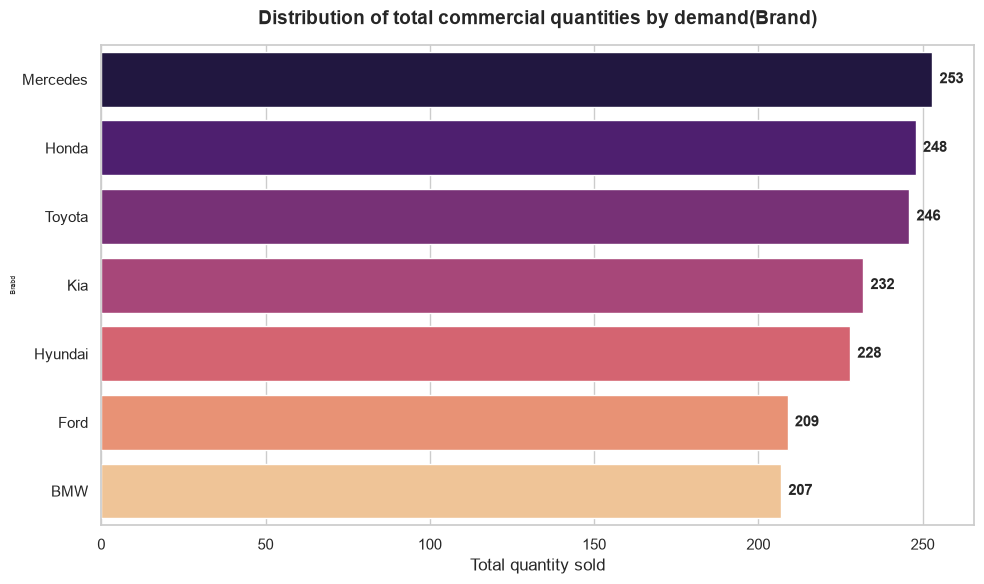

In [18]:
 
brand_sales = df.groupby("Brand")["Quantity"].sum().reset_index()
brand_sales = brand_sales.sort_values(by="Quantity", ascending=False)

import matplotlib.pyplot as plt
import seaborn as sns

brand_sales = df.groupby("Brand")["Quantity"].sum().reset_index()
brand_sales = brand_sales.sort_values(by="Quantity", ascending=False)

plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

ax = sns.barplot(
    data=brand_sales,
    x="Quantity",
    y="Brand",
    palette="magma"  
)

for container in ax.containers:
    ax.bar_label(container, padding=5, fontsize=11, fontweight='bold')

plt.title("Distribution of total commercial quantities by demand(Brand)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Total quantity sold", fontsize=12)
plt.ylabel("Brabd", fontsize=5)

plt.tight_layout()
plt.show()

## What is the highest-revenue Model?

In [19]:

df.groupby(["Brand", "Model"])["Revenue"].sum().sort_values(ascending=False).head(1)


Brand     Model
Mercedes  GLC      5770900.0
Name: Revenue, dtype: float64

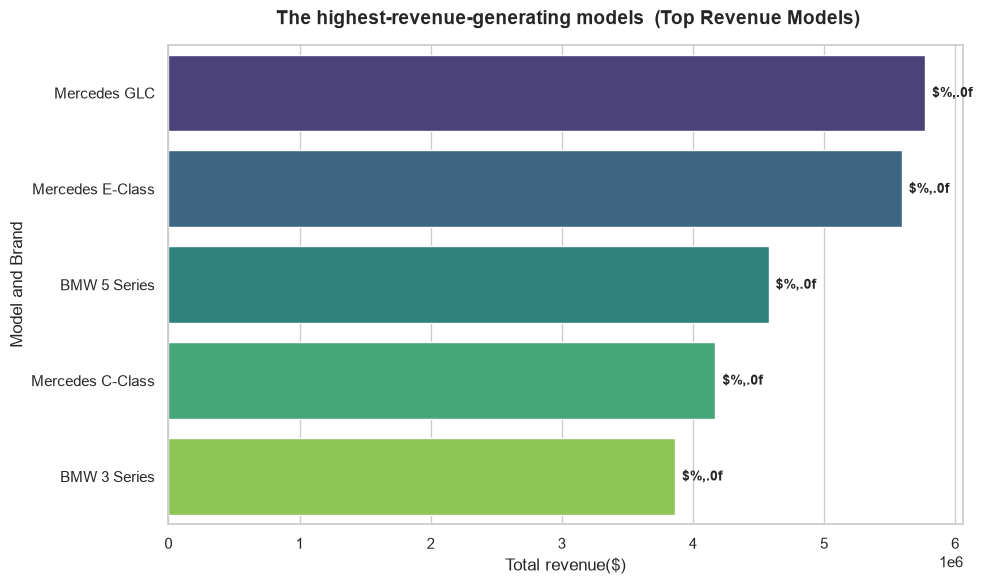

In [20]:
 


model_revenue = df.groupby(["Brand", "Model"])["Revenue"].sum().reset_index()
model_revenue["Full_Model"] = model_revenue["Brand"] + " " + model_revenue["Model"]
top_models = model_revenue.sort_values(by="Revenue", ascending=False).head(5)

plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

ax = sns.barplot(
    data=top_models,
    x="Revenue",
    y="Full_Model",
    hue="Full_Model",
    palette="viridis",
    legend=False
)

for container in ax.containers:
    ax.bar_label(container, fmt='$%,.0f', padding=5, fontsize=10, fontweight='bold')

plt.title(" The highest-revenue-generating models  (Top Revenue Models)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Total revenue($)", fontsize=12)
plt.ylabel("Model and Brand", fontsize=12)

plt.tight_layout()
plt.show()  

## Which City has the highest sales?

In [21]:
df.groupby(["City"])["Quantity"].sum().sort_values(ascending=False).head(1)

City
Madaba    254
Name: Quantity, dtype: int64

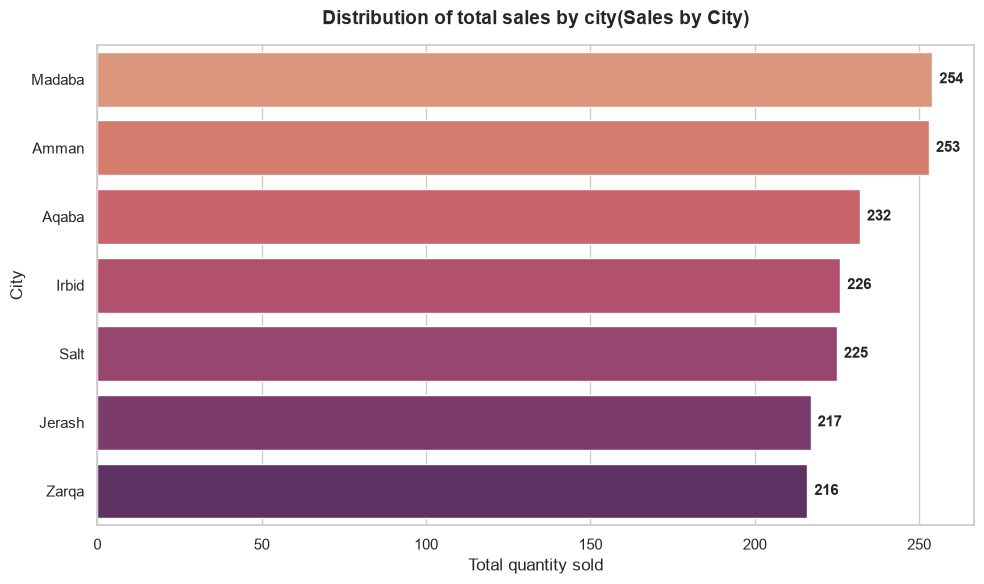

In [22]:
 

city_sales = df.groupby("City")["Quantity"].sum().reset_index()
city_sales = city_sales.sort_values(by="Quantity", ascending=False)

plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

ax = sns.barplot(
    data=city_sales,
    x="Quantity",
    y="City",
    hue="City",
    palette="flare",
    legend=False
)

for container in ax.containers:
    ax.bar_label(container, padding=5, fontsize=11, fontweight='bold')

plt.title("Distribution of total sales by city(Sales by City)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Total quantity sold", fontsize=12)
plt.ylabel( "City", fontsize=12)

plt.tight_layout()
plt.show()

## Which Month has the highest sales?

In [23]:

df["Date"] = pd.to_datetime(df["Date"])

df["Month"] = df["Date"].dt.month

top_month = df.groupby("Month")["Quantity"].sum().sort_values(ascending=False)
print(top_month)

Month
12    165
4     164
6     151
10    146
8     144
1     131
2     129
11    124
7     123
9     120
3     115
5     111
Name: Quantity, dtype: int64


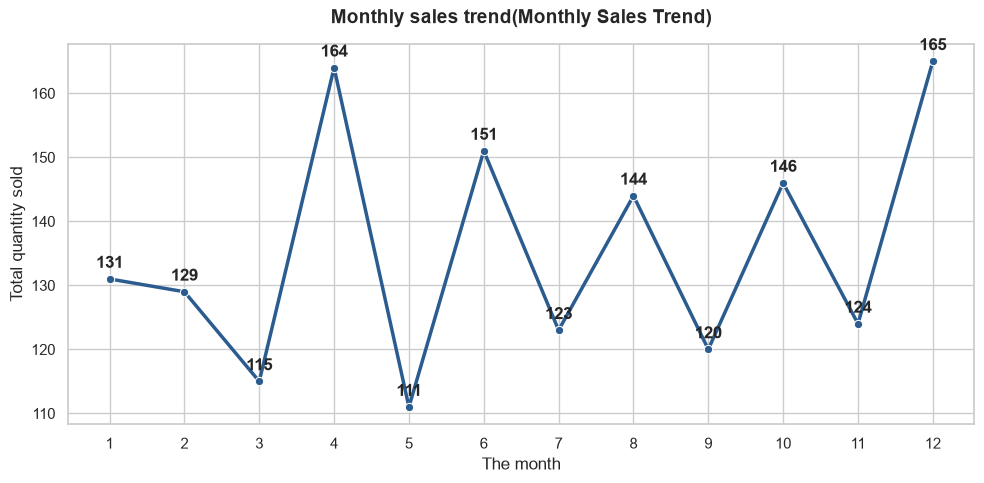

In [24]:
 
df["Date"] = pd.to_datetime(df["Date"])
df["Month"] = df["Date"].dt.month
monthly_sales = df.groupby("Month")["Quantity"].sum().reset_index()

plt.figure(figsize=(10, 5))
sns.set_theme(style="whitegrid")

ax = sns.lineplot(
    data=monthly_sales,
    x="Month",
    y="Quantity",
    marker="o",
    linewidth=2.5,
    color= "#2b5c8f"
)

for x, y in zip(monthly_sales["Month"], monthly_sales["Quantity"]):
    ax.annotate(f'{y}', (x, y), textcoords="offset points", xytext=(0, 8), ha='center', fontweight='bold')

plt.title("Monthly sales trend(Monthly Sales Trend)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("The month", fontsize=12)
plt.ylabel("Total quantity sold", fontsize=12)
plt.xticks(monthly_sales["Month"])  # إظهار أرقام الأشهر بوضوح

plt.tight_layout()
plt.show()

## What is the average car price?

In [25]:
df["Price"].mean()

np.float64(37385.3)

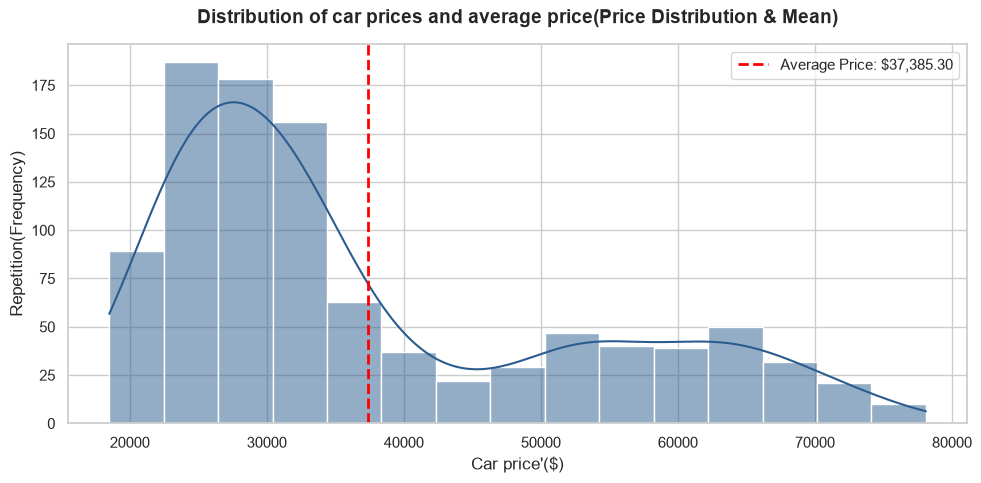

In [26]:
 

mean_price = df["Price"].mean()

plt.figure(figsize=(10, 5))
sns.set_theme(style="whitegrid")

ax = sns.histplot(df["Price"], kde=True, color="#2b5c8f", bins=15)

plt.axvline(mean_price, color='red', linestyle='--', linewidth=2, label=f'Average Price: ${mean_price:,.2f}')

plt.title("Distribution of car prices and average price(Price Distribution & Mean)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Car price'($)", fontsize=12)
plt.ylabel("Repetition(Frequency)", fontsize=12)
plt.legend(fontsize=11)

plt.tight_layout()
plt.show()

## Who is the best-performing Salesperson?

In [27]:
(df["Price"] * df["Quantity"]).groupby(df["Salesperson"]).sum().sort_values(ascending=False).head(1)

Salesperson
Noor    8293400.0
dtype: float64

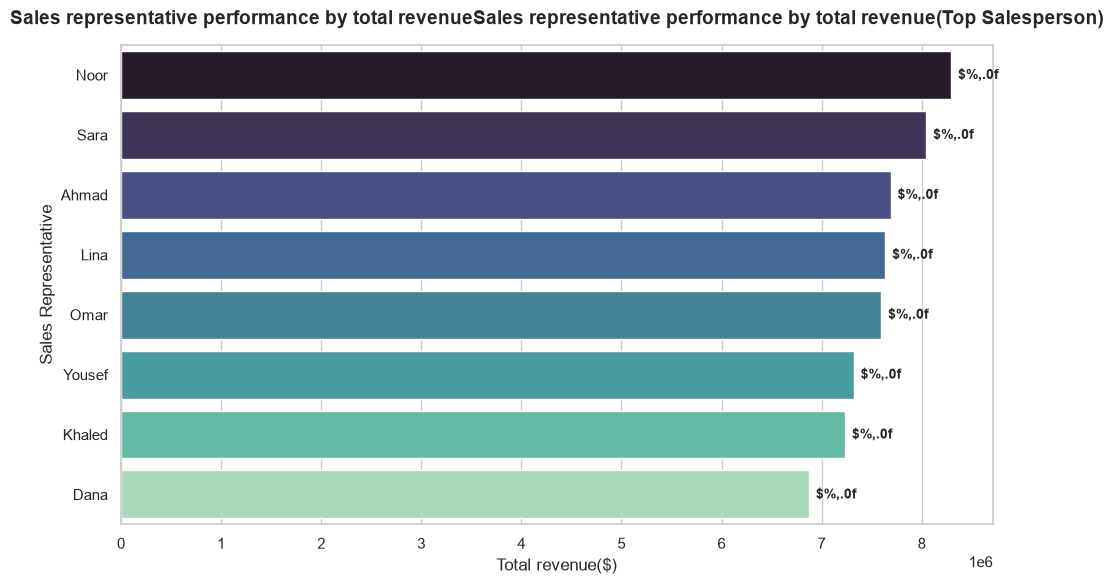

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

salesperson_rev = df.groupby("Salesperson")["Revenue"].sum().reset_index()
salesperson_rev = salesperson_rev.sort_values(by="Revenue", ascending=False)

plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

ax = sns.barplot(
    data=salesperson_rev,
    x="Revenue",
    y="Salesperson",
    hue="Salesperson",
    palette="mako",
    legend=False
)
for container in ax.containers:
    ax.bar_label(container, fmt='$%,.0f', padding=5, fontsize=10, fontweight='bold')

plt.title("Sales representative performance by total revenueSales representative performance by total revenue(Top Salesperson)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Total revenue($)", fontsize=12)
plt.ylabel("Sales Representative", fontsize=12)

plt.tight_layout()
plt.show()

## What is the most-used Payment Method?

In [29]:
df["Payment_Method"].value_counts().head(1)


Payment_Method
Credit Card    282
Name: count, dtype: int64

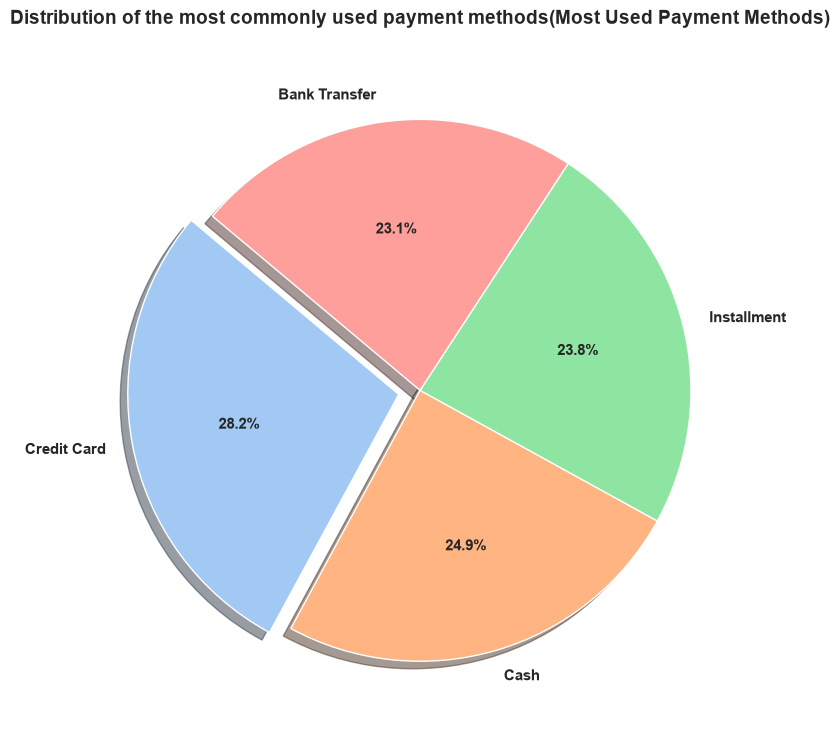

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

payment_counts = df["Payment_Method"].value_counts()

plt.figure(figsize=(8, 8))

colors = sns.color_palette("pastel")[0:len(payment_counts)]
explode = [0.08 if i == 0 else 0 for i in range(len(payment_counts))]  # إبراز الخيار الأول

plt.pie(
    payment_counts, 
    labels=payment_counts.index, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=colors, 
    explode=explode,
    shadow=True,
    textprops={'fontsize': 11, 'fontweight': 'bold'}
)

plt.title("Distribution of the most commonly used payment methods(Most Used Payment Methods)", fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

## Are newer cars more expensive than older cars?

In [31]:
sorted(df["Year"].unique())

[np.int64(2020),
 np.int64(2021),
 np.int64(2022),
 np.int64(2023),
 np.int64(2024),
 np.int64(2025)]

In [32]:
new_car = df["Year"] >= 2023
old_car = df["Year"] <= 2022

In [33]:
new_car

0      False
1       True
2       True
3      False
4       True
       ...  
995    False
996     True
997     True
998    False
999     True
Name: Year, Length: 1000, dtype: bool

In [34]:
new_models = df.loc[new_car]
old_models = df.loc[old_car]

In [35]:
print(f"new_models: {new_models["Price"].sum()} \nold_models: {old_models["Price"].sum()}")

new_models: 19539600.0 
old_models: 17845700.0


In [36]:
if new_models["Price"].sum() > old_models["Price"].sum():
    print("new is better")
else:
    print("old is better")

new is better


In [37]:
if new_models["Price"].median() > old_models["Price"].median():
    print("new is better")
else:
    print("old is better")

new is better


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_12256\3452673489.py:9: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax1 = sns.barplot(
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_12256\3452673489.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.barplot(
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_12256\3452673489.py:24: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax2 = sns.barplot(
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_12256\3452673489.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.barplot(


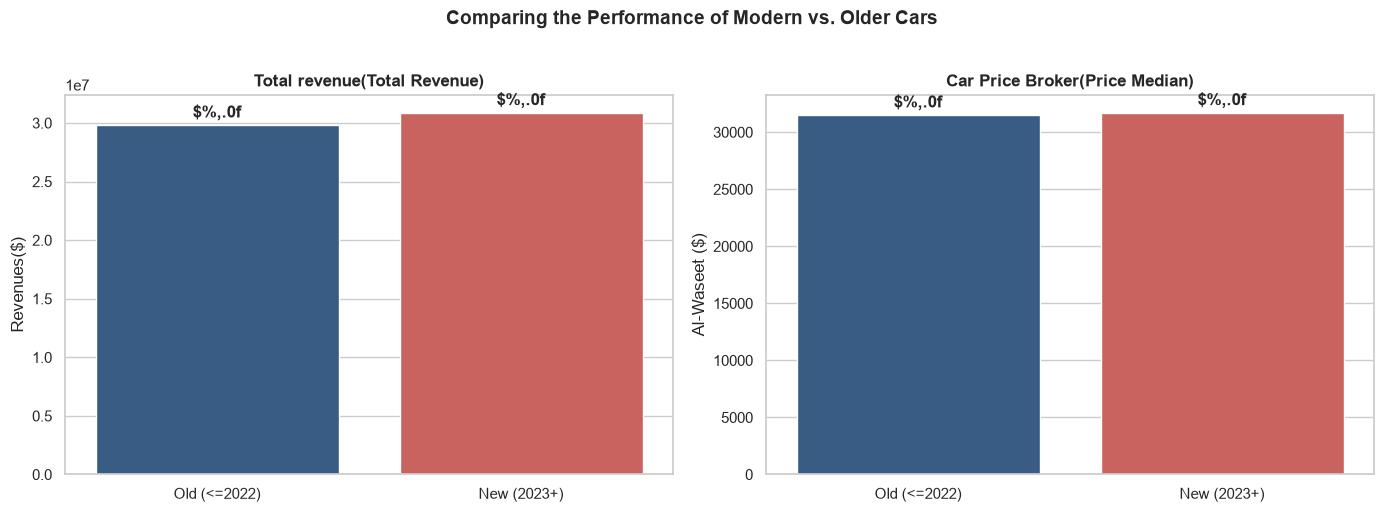

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

df["Car_Age_Group"] = df["Year"].apply(lambda x: "New (2023+)" if x >= 2023 else "Old (<=2022)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.set_theme(style="whitegrid")

ax1 = sns.barplot(
    data=df, 
    x="Car_Age_Group", 
    y="Revenue", 
    estimator=sum, 
    ci=None, 
    palette=["#2b5c8f", "#d9534f"], 
    ax=axes[0]
)
axes[0].set_title("Total revenue(Total Revenue)", fontsize=12, fontweight='bold')
axes[0].set_ylabel("Revenues($)")
axes[0].set_xlabel("")
for container in ax1.containers:
    ax1.bar_label(container, fmt='$%,.0f', padding=3, fontweight='bold')

ax2 = sns.barplot(
    data=df, 
    x="Car_Age_Group", 
    y="Price", 
    estimator=lambda x: x.median(), 
    ci=None, 
    palette=["#2b5c8f", "#d9534f"], 
    ax=axes[1]
)
axes[1].set_title("Car Price Broker(Price Median)", fontsize=12, fontweight='bold')
axes[1].set_ylabel("Al-Waseet ($)")
axes[1].set_xlabel("")
for container in ax2.containers:
    ax2.bar_label(container, fmt='$%,.0f', padding=3, fontweight='bold')

plt.suptitle("Comparing the Performance of Modern vs. Older Cars", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [39]:
df["Price"]>50000
df[
    df["Price"]>50000 
]

,Sale_ID,Date,Brand,Model,Year,Price,Quantity,City,Salesperson,Payment_Method,Customer_Age,Revenue,Month,Car_Age_Group
5,6,2025-09-21,BMW,3 Series,2021,51100.0,2,Jerash,Sara,Credit Card,37.0,102200.0,9,Old (<=2022)
7,8,2025-07-09,BMW,5 Series,2021,69500.0,2,Salt,Dana,Cash,38.0,139000.0,7,Old (<=2022)
10,11,2025-08-19,Mercedes,GLC,2020,63700.0,1,Irbid,Ahmad,Installment,27.0,63700.0,8,Old (<=2022)
15,16,2025-08-31,Mercedes,C-Class,2023,59000.0,1,Madaba,Lina,Credit Card,26.0,59000.0,8,New (2023+)
26,27,2025-05-24,BMW,X3,2025,61900.0,2,Irbid,Dana,Cash,22.0,123800.0,5,New (2023+)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
987,988,2025-05-18,BMW,5 Series,2021,60400.0,1,Zarqa,Omar,Credit Card,32.0,60400.0,5,Old (<=2022)
992,993,2025-08-02,Mercedes,E-Class,2024,60500.0,1,Madaba,Dana,Cash,53.0,60500.0,8,New (2023+)
993,994,2025-07-21,BMW,5 Series,2023,54600.0,1,Aqaba,Yousef,Installment,33.0,54600.0,7,New (2023+)
997,998,2025-03-01,Mercedes,C-Class,2025,53800.0,1,Salt,Ahmad,Cash,26.0,53800.0,3,New (2023+)


In [40]:
df["City"]=="Amman"
df[
    df["City"]=="Amman"
]

,Sale_ID,Date,Brand,Model,Year,Price,Quantity,City,Salesperson,Payment_Method,Customer_Age,Revenue,Month,Car_Age_Group
16,17,2025-12-14,Hyundai,Sonata,2025,28700.0,1,Amman,Khaled,Credit Card,53.0,28700.0,12,New (2023+)
25,26,2025-12-26,Honda,Civic,2020,24700.0,1,Amman,Sara,Installment,45.0,24700.0,12,Old (<=2022)
27,28,2025-01-09,Toyota,Camry,2023,32000.0,1,Amman,Sara,Bank Transfer,36.0,32000.0,1,New (2023+)
37,38,2025-04-14,Honda,CR-V,2021,38000.0,1,Amman,Ahmad,Bank Transfer,59.0,38000.0,4,Old (<=2022)
41,42,2025-04-11,Toyota,Camry,2025,29800.0,1,Amman,Dana,Cash,25.0,29800.0,4,New (2023+)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
957,958,2025-10-22,Honda,Accord,2021,30400.0,1,Amman,Ahmad,Installment,30.0,30400.0,10,Old (<=2022)
973,974,2025-10-23,Mercedes,GLC,2025,54200.0,2,Amman,Yousef,Cash,43.0,108400.0,10,New (2023+)
989,990,2025-04-20,Toyota,Camry,2023,29200.0,1,Amman,Ahmad,Cash,40.0,29200.0,4,New (2023+)
991,992,2025-09-29,Toyota,Camry,2022,33200.0,3,Amman,Sara,Cash,59.0,99600.0,9,Old (<=2022)


In [41]:
df["Quantity"]>1
df[
    df["Quantity"]>1
]

,Sale_ID,Date,Brand,Model,Year,Price,Quantity,City,Salesperson,Payment_Method,Customer_Age,Revenue,Month,Car_Age_Group
0,1,2025-04-13,Honda,Civic,2022,27300.0,3,Irbid,Sara,Bank Transfer,31.0,81900.0,4,Old (<=2022)
2,3,2025-11-10,Ford,Fusion,2023,24200.0,2,Madaba,Yousef,Installment,45.0,48400.0,11,New (2023+)
3,4,2025-07-07,Toyota,RAV4,2022,35600.0,2,Jerash,Noor,Credit Card,23.0,71200.0,7,Old (<=2022)
5,6,2025-09-21,BMW,3 Series,2021,51100.0,2,Jerash,Sara,Credit Card,37.0,102200.0,9,Old (<=2022)
7,8,2025-07-09,BMW,5 Series,2021,69500.0,2,Salt,Dana,Cash,38.0,139000.0,7,Old (<=2022)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
985,986,2025-06-01,Hyundai,Tucson,2024,31300.0,3,Madaba,Omar,Credit Card,36.0,93900.0,6,New (2023+)
990,991,2025-04-15,Kia,Sportage,2023,29200.0,3,Madaba,Omar,Installment,59.0,87600.0,4,New (2023+)
991,992,2025-09-29,Toyota,Camry,2022,33200.0,3,Amman,Sara,Cash,59.0,99600.0,9,Old (<=2022)
998,999,2025-01-14,Kia,Sportage,2021,33900.0,3,Aqaba,Lina,Cash,35.0,101700.0,1,Old (<=2022)


In [42]:
df.sort_values("Revenue",ascending=False).head(10)

,Sale_ID,Date,Brand,Model,Year,Price,Quantity,City,Salesperson,Payment_Method,Customer_Age,Revenue,Month,Car_Age_Group
409,410,2025-10-21,Mercedes,E-Class,2024,77300.0,3,Madaba,Noor,Credit Card,38.0,231900.0,10,New (2023+)
182,183,2025-01-08,Mercedes,E-Class,2020,75800.0,3,Jerash,Sara,Credit Card,27.0,227400.0,1,Old (<=2022)
845,846,2025-06-30,Mercedes,E-Class,2022,73300.0,3,Aqaba,Lina,Installment,56.0,219900.0,6,Old (<=2022)
900,901,2025-07-17,Mercedes,E-Class,2020,73100.0,3,Salt,Omar,Bank Transfer,35.0,219300.0,7,Old (<=2022)
664,665,2025-11-09,Mercedes,E-Class,2022,72600.0,3,Jerash,Yousef,Credit Card,60.0,217800.0,11,Old (<=2022)
739,740,2025-07-11,Mercedes,E-Class,2023,71700.0,3,Aqaba,Noor,Credit Card,32.0,215100.0,7,New (2023+)
630,631,2025-03-05,Mercedes,E-Class,2021,71100.0,3,Madaba,Lina,Credit Card,58.0,213300.0,3,Old (<=2022)
86,87,2025-05-02,Mercedes,GLC,2024,69700.0,3,Zarqa,Sara,Cash,25.0,209100.0,5,New (2023+)
553,554,2025-07-14,BMW,5 Series,2022,69700.0,3,Irbid,Sara,Installment,35.0,209100.0,7,Old (<=2022)
61,62,2025-06-17,BMW,5 Series,2023,69100.0,3,Irbid,Ahmad,Credit Card,47.0,207300.0,6,New (2023+)


### What is the Brand with the highest Revenue?

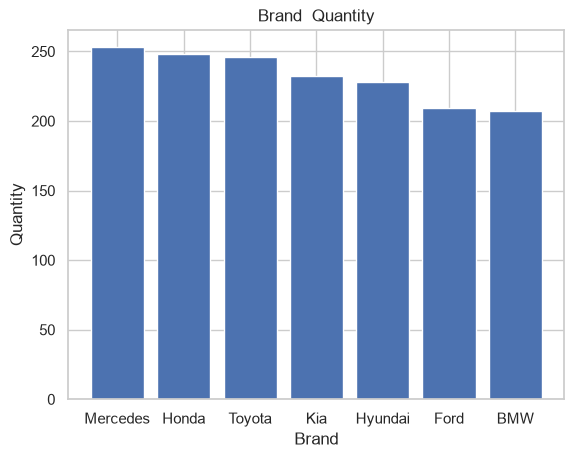

In [43]:
#Sales by Brand
brand_groups=df.groupby("Brand")["Quantity"].sum().sort_values(ascending=False)
plt.bar(brand_groups.index,brand_groups.values)
plt.title("Brand  Quantity")
plt.xlabel("Brand")
plt.ylabel("Quantity")
plt.show()

### Which Brand generates the highest Revenue?

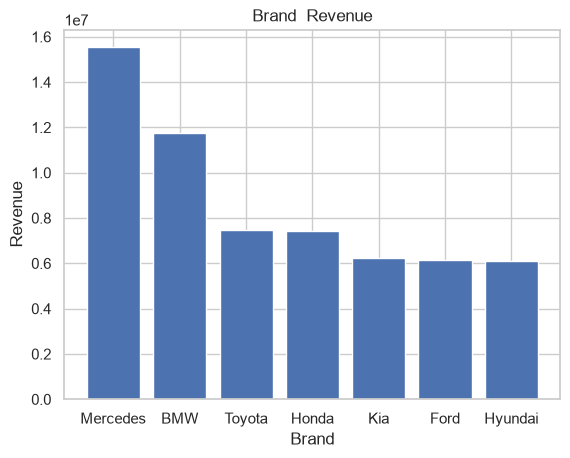

In [44]:
#Revenue by Brand
df_group=df.groupby("Brand")["Revenue"].sum().sort_values(ascending=False)
plt.bar(df_group.index,df_group.values)
plt.title("Brand  Revenue")
plt.xlabel("Brand")
plt.ylabel("Revenue")
plt.show()

### Which City has the highest sales?

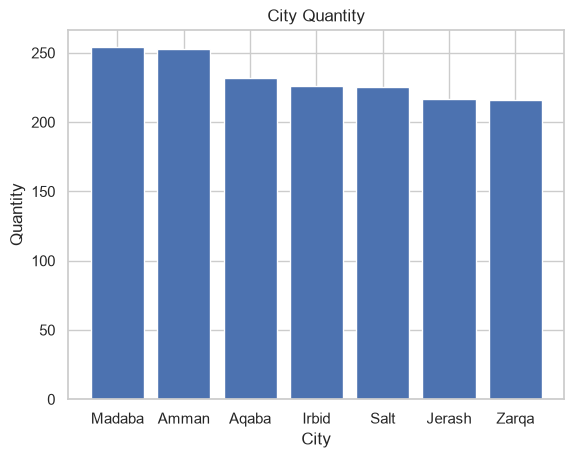

In [45]:
# Sales by City
df_group=df.groupby("City")["Quantity"].sum().sort_values(ascending=False)
plt.bar(df_group.index,df_group.values)
plt.title("City Quantity")
plt.xlabel("City")
plt.ylabel("Quantity")
plt.show()


### Which Month generates the highest Revenue?

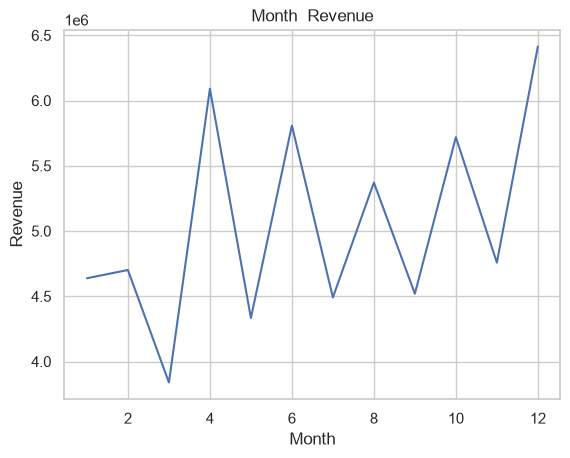

In [46]:
# Monthly Revenue
df_group=df.groupby("Month")["Revenue"].sum()
plt.plot(df_group.index,df_group.values)
plt.title("Month  Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

### Which Payment Method generates the highest Revenue?

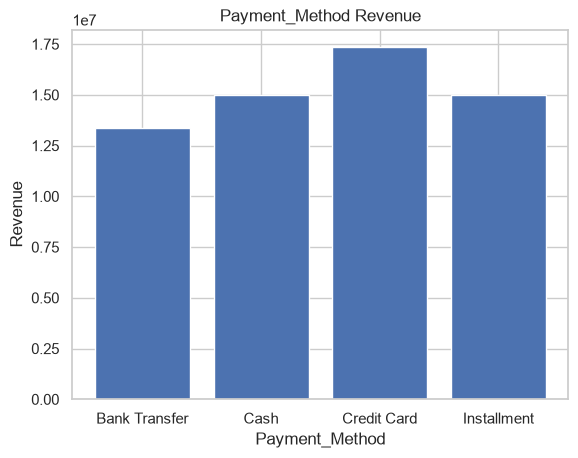

In [47]:
#Revenue by Payment Method
df_group=df.groupby("Payment_Method")["Revenue"].sum()
plt.bar(df_group.index,df_group.values)
plt.title("Payment_Method Revenue" )
plt.xlabel("Payment_Method")
plt.ylabel("Revenue")

plt.show()




# Business Insight:

## What is the best-selling Brand?

In [48]:
brand_groups = df.groupby(["Brand"])
brand_groups["Quantity"].sum().sort_values(ascending=False).head(1)

Brand
Mercedes    253
Name: Quantity, dtype: int64

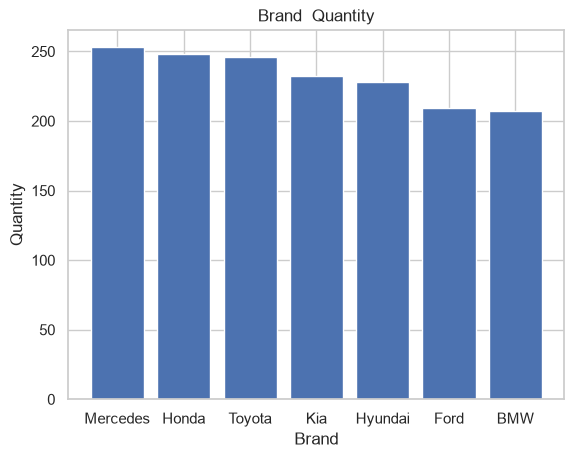

In [49]:
brand_groups=df.groupby("Brand")["Quantity"].sum().sort_values(ascending=False)
plt.bar(brand_groups.index,brand_groups.values)
plt.title("Brand  Quantity")
plt.xlabel("Brand")
plt.ylabel("Quantity")
plt.show()

**Business Insight:** Mercedes was the best-selling brand, with 253 cars sold.

## Which Brand generates the highest Revenue?

In [50]:
df.groupby("Brand")["Revenue"].sum().sort_values(ascending=False).head(1)

Brand
Mercedes    15536000.0
Name: Revenue, dtype: float64

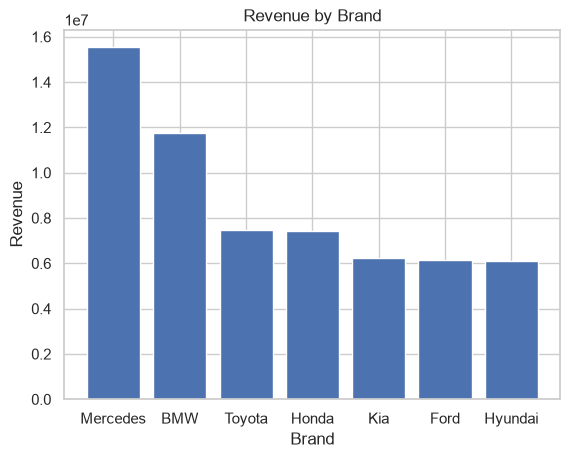

In [51]:
df_group = df.groupby("Brand")["Revenue"].sum().sort_values(ascending=False)

plt.bar(df_group.index, df_group.values)

plt.title("Revenue by Brand")
plt.xlabel("Brand")
plt.ylabel("Revenue")

plt.show()

**Business Insight:** Mercedes generated the highest total revenue among all brands.

## Which Model generates the highest Revenue?

In [52]:
df.groupby(["Brand", "Model"])["Revenue"].sum().sort_values(ascending=False).head(1)

Brand     Model
Mercedes  GLC      5770900.0
Name: Revenue, dtype: float64

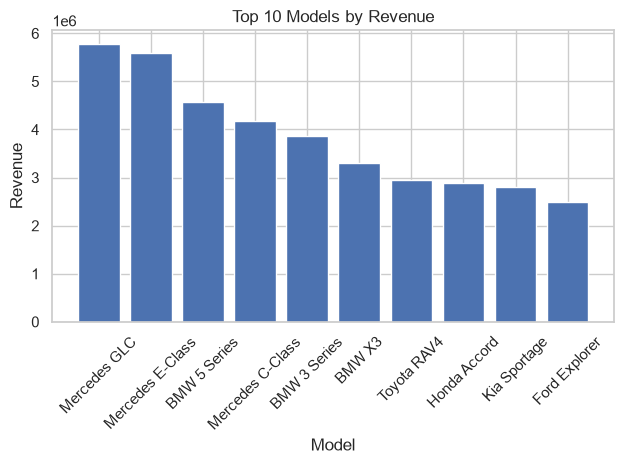

In [53]:
# Revenue by Model

df_group = (
    df.groupby(["Brand", "Model"])["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

labels = [f"{brand} {model}" for brand, model in df_group.index]

plt.bar(labels, df_group.values)

plt.title("Top 10 Models by Revenue")
plt.xlabel("Model")
plt.ylabel("Revenue")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

**Business Insight:** The Mercedes GLC was the highest-revenue model, generating 5.77 million in total revenue.

## Which City has the highest sales?

In [54]:
df.groupby("City")["Quantity"].sum().sort_values(ascending=False).head(1)

City
Madaba    254
Name: Quantity, dtype: int64

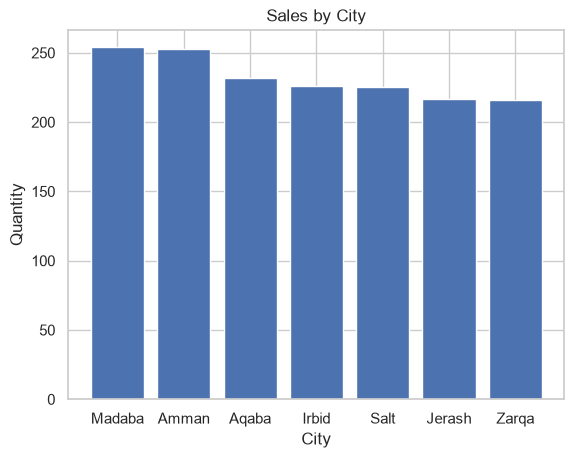

In [55]:
df_group = df.groupby("City")["Quantity"].sum().sort_values(ascending=False)

plt.bar(df_group.index, df_group.values)

plt.title("Sales by City")
plt.xlabel("City")
plt.ylabel("Quantity")

plt.show()

**Business Insight:** Madaba recorded the highest sales volume, with 254 cars sold.

## Which Salesperson generates the highest Revenue?

In [56]:
df.groupby("Salesperson")["Revenue"].sum().sort_values(ascending=False).head(1)

Salesperson
Noor    8293400.0
Name: Revenue, dtype: float64

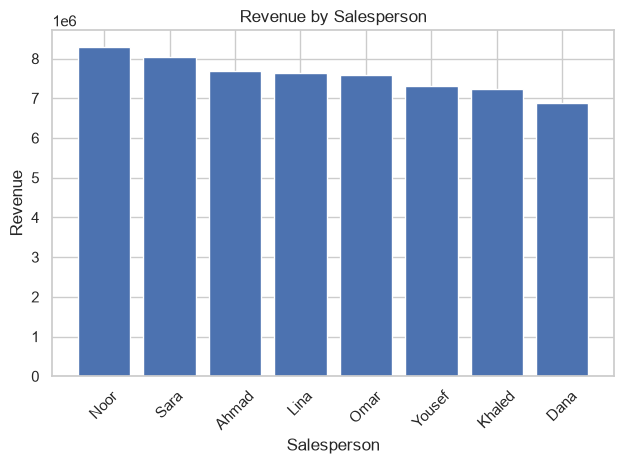

In [57]:
# Revenue by Salesperson

df_group = df.groupby("Salesperson")["Revenue"].sum().sort_values(ascending=False)

plt.bar(df_group.index, df_group.values)

plt.title("Revenue by Salesperson")
plt.xlabel("Salesperson")
plt.ylabel("Revenue")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

**Business Insight:** Noor generated the highest total revenue among all salespeople, with 8.29 million.

## What is the most frequently used Payment Method?

In [58]:
df["Payment_Method"].value_counts().head(1)

Payment_Method
Credit Card    282
Name: count, dtype: int64

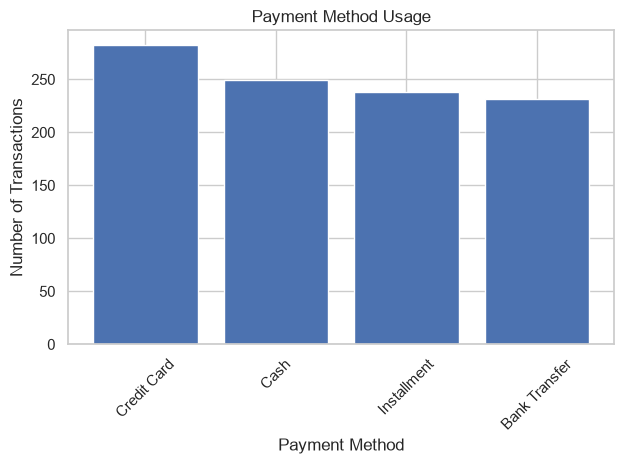

In [59]:
# Payment Method Usage

df_group = df["Payment_Method"].value_counts()

plt.bar(df_group.index, df_group.values)

plt.title("Payment Method Usage")
plt.xlabel("Payment Method")
plt.ylabel("Number of Transactions")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

**Business Insight:** Credit Card was the most frequently used payment method, with 282 transactions.

## What is the average car price?

In [60]:
df["Price"].mean()

np.float64(37385.3)

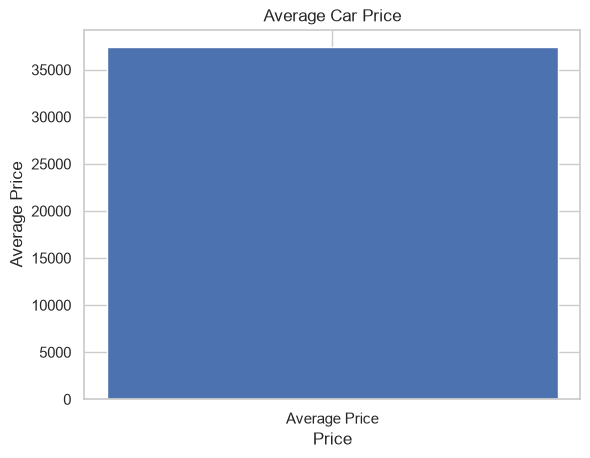

In [61]:
# Average Car Price

average_price = df["Price"].mean()

plt.bar(["Average Price"], [average_price])

plt.title("Average Car Price")
plt.xlabel("Price")
plt.ylabel("Average Price")

plt.show()

**Business Insight:** The average car price was approximately 37,385.

## Which Month has the highest Revenue?

In [62]:
# Monthly Revenue

df_group = df.groupby("Month")["Revenue"].sum()

df_group.sort_values(ascending=False).head(1)

Month
12    6414400.0
Name: Revenue, dtype: float64

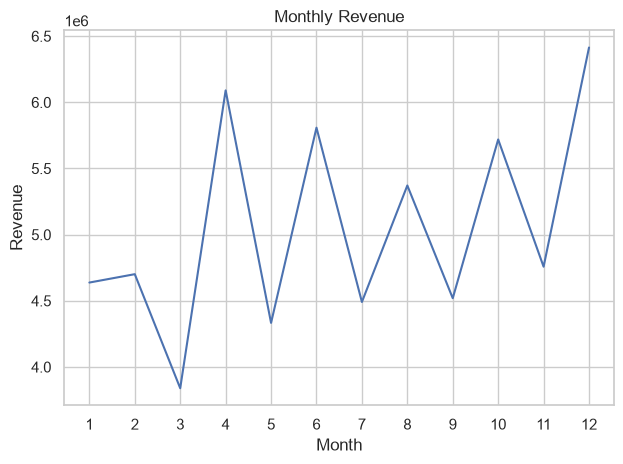

In [63]:
# Monthly Revenue

df_group = df.groupby("Month")["Revenue"].sum()

plt.plot(df_group.index, df_group.values)

plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.xticks(range(1, 13))
plt.tight_layout()

plt.show()

**Business Insight:** December recorded the highest total revenue among all months.

## Which Payment Method generates the highest Revenue?

In [64]:
df.groupby("Payment_Method")["Revenue"].sum().sort_values(ascending=False).head(1)

Payment_Method
Credit Card    17343300.0
Name: Revenue, dtype: float64

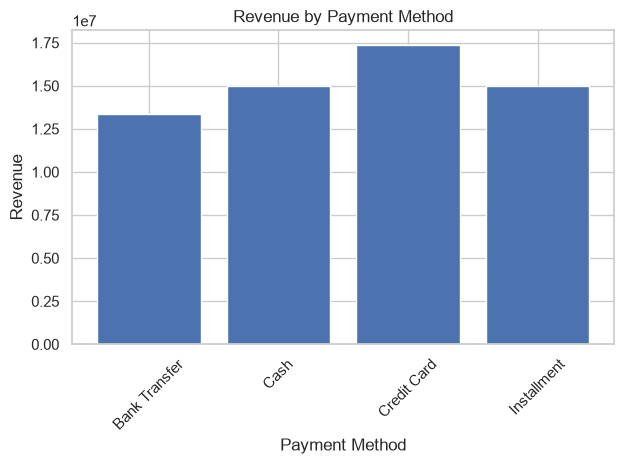

In [66]:
# Revenue by Payment Method

df_group = df.groupby("Payment_Method")["Revenue"].sum()

plt.bar(df_group.index, df_group.values)

plt.title("Revenue by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Revenue")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

**Business Insight:** Credit Card generated the highest total revenue among the payment methods.

# Conclusion

This project analyzed car sales data to understand sales performance and identify important business patterns. The analysis showed that Mercedes was the best-selling brand, while the Mercedes GLC generated the highest revenue among models. Madaba recorded the highest sales volume, and Noor generated the highest revenue among salespeople. December had the highest total revenue, and Credit Card was the most frequently used payment method. The average car price was approximately 37,385.